<a href="https://colab.research.google.com/github/armandokeller/gerador-pwl/blob/main/Gerador_de_PWL_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ferramenta para plotar sinais e gerar arquivos PWL

Desenvolvido por Armando L. Keller (Unisinos)


## Instalar a bibliteca lcapy e importar as demais bibliotecas

necessário executar apenas uma vez

In [17]:
# Instala e importa todas as bibliotecas necessárias

!pip install lcapy

import numpy as np
import matplotlib.pyplot as plt
from lcapy import u,t,exp,ramp,delta
import sympy as sp
from sympy.utilities.lambdify import lambdify

## Definição do sinal e dos parâmetros

Definir o nome do arquivo a ser exportado, o tempo total da simulação (final do eixo horizontal do gráfico), e a expressão a ser plotada.

Para a expressão, podem ser utilizadas funções matemáticas gerais, e delta(t) para o impulso unitário, u(t) para o degrau, e a rampa pode ser escrita como t*u(t).

In [25]:


# --- Parâmetros definidos pelo usuário --- #

nome_arquivo = "sinal.txt"
tempo_final = 5 # Tempo final para a simulação/plotagem

# Número de pontos para discretizar o tempo (100e3 = 100.000 pontos)
pontos = int(100e3)

# Expressão do sinal a ser analisado. Variáveis simbólicas 't' e função degrau 'u(t)' são usadas, a rampa pode ser escrita como t*u(t)
# expressao = 10*t*u(t) -20*(t-2)*u(t-2)+10*(t-4)*u(t-4)
expressao = 10*t*u(t)-10*(t-2)*u(t-2)

print("Parâmetros definidos com sucesso")

Parâmetros definidos com sucesso


## Plotar o gráfico

Depois de alterar os parâmetros no bloco anterior, é possível gerar o gráfico. Edite a formatação do gráfico se for necessário.

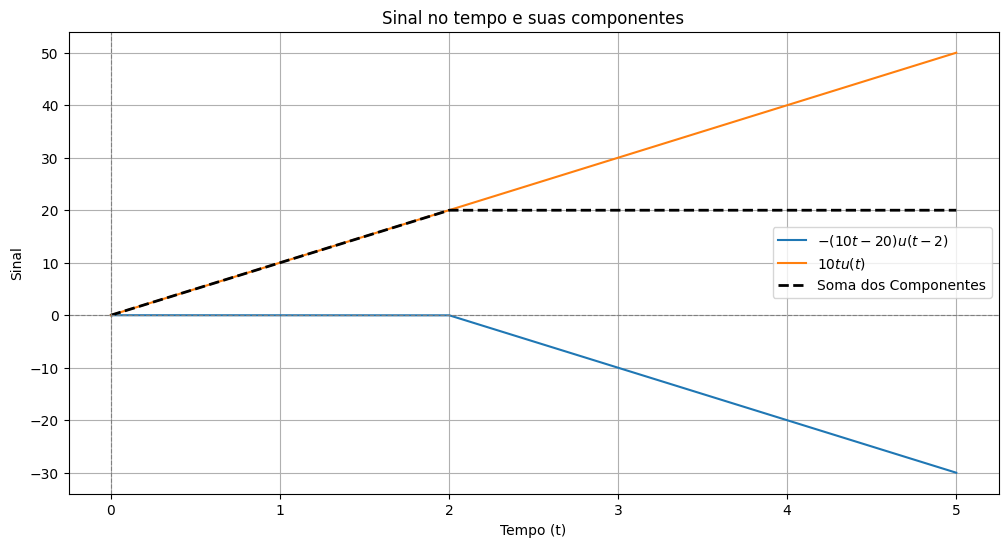

In [26]:
# Plotar gráfico
tempo = np.linspace(-0.0000000000000000000001, tempo_final, pontos)
sinal = expressao.evaluate(tempo)
sympy_expressao = expressao.expr
t_sym = sympy_expressao.free_symbols.pop() if sympy_expressao.free_symbols else sp.symbols('t')
componentes = sp.Add.make_args(sympy_expressao)


plt.figure(figsize=(12, 6))
for i, componente in enumerate(componentes):
    component_func = lambdify(t_sym, componente, modules=[{'Heaviside': np.heaviside}, 'numpy'])
    component_sinal = component_func(tempo)
    component_label_tex = sp.latex(componente).replace("\\theta","u")
    plt.plot(tempo, component_sinal, label=f'${component_label_tex}$')


sum_func = lambdify(t_sym, sympy_expressao, modules=[{'Heaviside': np.heaviside}, 'numpy'])
sum_sinal = sum_func(tempo)
plt.plot(tempo, sum_sinal, label='Soma dos Componentes', linestyle='--', linewidth=2, color='black')


plt.title('Sinal no tempo e suas componentes')
plt.xlabel('Tempo (t)')
plt.ylabel('Sinal')
plt.legend()
plt.grid(True)


plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.show()

## Exportar sinal

Realiza a exportação do sinal em um arquivo txt com duas colunas, sendo a primeira o tempo e a segunda o valor do sinal (tensão, corrente...). Este sinal pode ser utilizado em simuladores de circuitos elétricos como LT Spice (ver a opção PWL nas fontes), ou até para plotar o gráfico em outros softwares como o Microsoft Excel.

Para baixar o arquivo, olhe no ícone de pasta no menu a esqueda (Arquivos).

In [27]:
with open(nome_arquivo, 'w') as arquivo:
  for t_val, s_val in zip(tempo, sinal):
    arquivo.write(f'{t_val},{s_val}\n')

print(f"Dados exportados para {nome_arquivo}.")

Dados exportados para sinal.txt.
